<a href="https://colab.research.google.com/github/HarshiniArulmani2006/Harshini-codeboosters-2026/blob/main/Day_3/Day_3_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import requests #so only api will work

In [14]:
API_KEY='3929e5e1d84f27eadb79dc0459e00d9b'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Mumbai','Delhi','Tiruppur','Chennai','Pollachi','Kolkata','Pune','Jaipur']
print(f'API configured for {len(CITIES)} cities')
print(f'Cities:{CITIES}')
print('\nMy API key: 3929e5e1d84f27eadb79dc0459e00d9b')

API configured for 8 cities
Cities:['Mumbai', 'Delhi', 'Tiruppur', 'Chennai', 'Pollachi', 'Kolkata', 'Pune', 'Jaipur']

My API key: 3929e5e1d84f27eadb79dc0459e00d9b


In [15]:
def fetch_weather(city, api_key):
    """
    Fetch current weather data for a given city.
    """
    params={
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }
    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        if response.status_code==200:
            data = response.json()
            return {
                'city': city,
                'temperature': round(data['main']['temp'], 1),
                'feels_like': round(data['main']['feels_like'], 1),
                'humidity': data['main']['humidity'],
                'pressure': data['main']['pressure'],
                'wind_speed': data['wind']['speed'],
                'condition': data['weather'][0]['description'].title(),
                'visibility': data.get('visibility', 0) // 1000
            }
        else:
            print(f"ERROR {response.status_code} for {city}:{response.json().get('message')}")
            return None
    except requests.exceptions.ConnectionError:
        print(f'Connection Error for {city} - check internet connection')
        return None
print('Calling Weather API...')
weather_records=[]
for city in CITIES:
    print(f'Fetching: {city}...', end=' ')
    record=fetch_weather(city, API_KEY)
    if record:
        weather_records.append(record)
        print(f"{record['temperature']}°C,{record['condition']}")
    else:
        print('FAILED')
print(f'Successfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weather API...
Fetching: Mumbai... 33.0°C,Haze
Fetching: Delhi... 44.0°C,Clear Sky
Fetching: Tiruppur... 35.1°C,Overcast Clouds
Fetching: Chennai... 35.9°C,Few Clouds
Fetching: Pollachi... 33.8°C,Overcast Clouds
Fetching: Kolkata... 32.0°C,Haze
Fetching: Pune... 36.3°C,Overcast Clouds
Fetching: Jaipur... 42.6°C,Haze
Successfully fetched: 8/8 cities


In [17]:
def fetch_weather(city, api_key):
    """
    Fetch current weather data for a given city.
    """
    params={
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }
    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        if response.status_code==200:
            data = response.json()
            return {
                'city': city,
                'temperature': round(data['main']['temp'], 1),
                'feels_like': round(data['main']['feels_like'], 1),
                'humidity': data['main']['humidity'],
                'pressure': data['main']['pressure'],
                'wind_speed': data['wind']['speed'],
                'condition': data['weather'][0]['description'].title(),
                'visibility': data.get('visibility', 0) // 1000
            }
        else:
            print(f"ERROR {response.status_code} for {city}:{response.json().get('message')}")
            return None
    except requests.exceptions.ConnectionError:
        print(f'Connection Error for {city} - check internet connection')
        return None
print('Calling Weather API...')
weather_records=[]
for city in CITIES:
    print(f'Fetching: {city}...', end=' ')
    record=fetch_weather(city, API_KEY)
    if record:
        weather_records.append(record)
        print(f"{record['temperature']}°C,{record['condition']}")
        print(record)
    else:
        print('FAILED')
print(f'Successfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weather API...
Fetching: Mumbai... 33.0°C,Haze
{'city': 'Mumbai', 'temperature': 33.0, 'feels_like': 38.8, 'humidity': 58, 'pressure': 1009, 'wind_speed': 4.63, 'condition': 'Haze', 'visibility': 7}
Fetching: Delhi... 44.0°C,Clear Sky
{'city': 'Delhi', 'temperature': 44.0, 'feels_like': 41.1, 'humidity': 10, 'pressure': 999, 'wind_speed': 5.14, 'condition': 'Clear Sky', 'visibility': 7}
Fetching: Tiruppur... 35.1°C,Overcast Clouds
{'city': 'Tiruppur', 'temperature': 35.1, 'feels_like': 37.4, 'humidity': 40, 'pressure': 1007, 'wind_speed': 5.72, 'condition': 'Overcast Clouds', 'visibility': 10}
Fetching: Chennai... 35.9°C,Few Clouds
{'city': 'Chennai', 'temperature': 35.9, 'feels_like': 42.9, 'humidity': 54, 'pressure': 1005, 'wind_speed': 5.14, 'condition': 'Few Clouds', 'visibility': 6}
Fetching: Pollachi... 33.8°C,Overcast Clouds
{'city': 'Pollachi', 'temperature': 33.8, 'feels_like': 37.0, 'humidity': 47, 'pressure': 1008, 'wind_speed': 8.11, 'condition': 'Overcast Clouds', 

In [18]:
#build data frame from API results
weather_df=pd.DataFrame(weather_records)
print('Weather DataFrame created:')
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values:{weather_df.isnull().sum().sum()}')
print(f'\nData types:')
print(weather_df.dtypes)

Weather DataFrame created:
    city  temperature  feels_like  humidity  pressure  wind_speed       condition  visibility
  Mumbai         33.0        38.8        58      1009        4.63            Haze           7
   Delhi         44.0        41.1        10       999        5.14       Clear Sky           7
Tiruppur         35.1        37.4        40      1007        5.72 Overcast Clouds          10
 Chennai         35.9        42.9        54      1005        5.14      Few Clouds           6
Pollachi         33.8        37.0        47      1008        8.11 Overcast Clouds          10
 Kolkata         32.0        38.9        66      1001        3.60            Haze           5
    Pune         36.3        35.7        26      1008        3.76 Overcast Clouds          10
  Jaipur         42.6        40.9        14      1001        5.66            Haze           5

Shape: (8, 8)
Missing values:0

Data types:
city            object
temperature    float64
feels_like     float64
humidity     

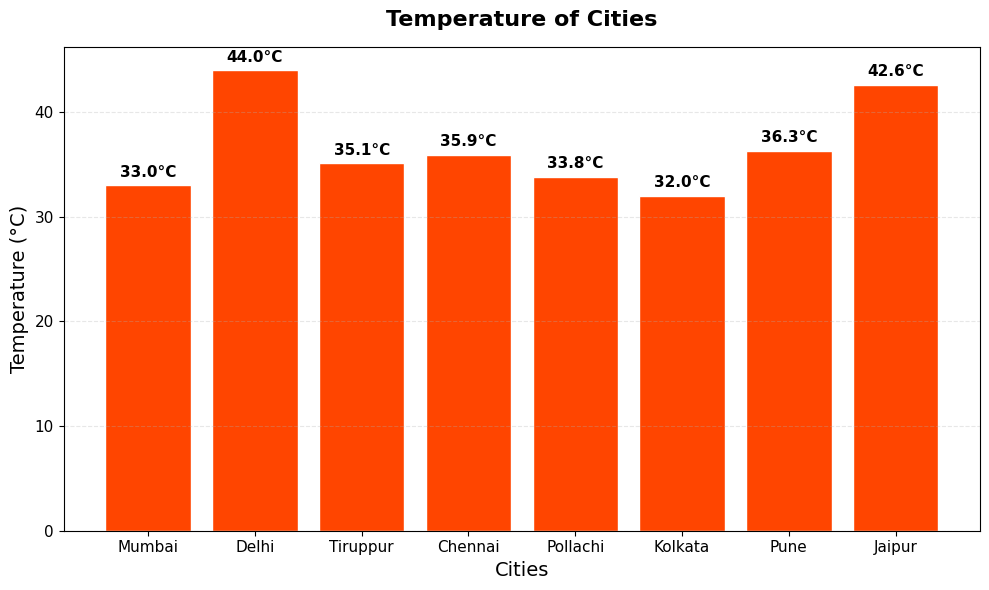

In [22]:
#plt.figure(figsize=(10,6))
#plt.bar(weather_df[city],
 #       weather_df[temperature])
#plt.title('Temperature of Cities')
#plt.xlabel('Cities')
#plt.ylabel('Temperature (°C)')
#plt.show()

weather_df=pd.DataFrame(weather_records)
fig, ax=plt.subplots(figsize=(10, 6))
bars=ax.bar(
    weather_df['city'],
    weather_df['temperature'],
    color='#FF4500',
    edgecolor='white',
    linewidth=1
)
for bar in bars:
    height=bar.get_height()
    ax.text(
        bar.get_x()+bar.get_width()/2,
        height+0.5,
        f"{height}°C",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black'
    )
ax.set_title(
    "Temperature of Cities",
    fontsize=16,
    fontweight='bold',
    pad=15
)
ax.set_xlabel("Cities",fontsize=14)
ax.set_ylabel("Temperature (°C)",fontsize=14)
ax.tick_params(axis='x',labelsize=11)
ax.tick_params(axis='y',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()